In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
print("TensorFlow Version:", tf.__version__)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("GPU is available and ready!")
else:
    print("GPU is not available. Go to Runtime > Change runtime type > GPU")

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available and ready!


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "jonathanoheix/face-expression-recognition-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 121M/121M [00:00<00:00, 159MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jonathanoheix/face-expression-recognition-dataset/versions/1


In [4]:
print("Dataset path:")
print(path)

print("\nFiles and folders:")

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "    " * level
    print(indent + os.path.basename(root) + "/")

    subindent = "    " * (level + 1)

    for file in files[:5]:
        print(subindent + file)

Dataset path:
/root/.cache/kagglehub/datasets/jonathanoheix/face-expression-recognition-dataset/versions/1

Files and folders:
1/
    images/
        images/
            validation/
                happy/
                    12581.jpg
                    27333.jpg
                    5490.jpg
                    6095.jpg
                    5705.jpg
                surprise/
                    32420.jpg
                    15922.jpg
                    12134.jpg
                    35384.jpg
                    4199.jpg
                neutral/
                    21880.jpg
                    25743.jpg
                    8863.jpg
                    13800.jpg
                    16463.jpg
                sad/
                    13726.jpg
                    3634.jpg
                    25351.jpg
                    31113.jpg
                    18180.jpg
                disgust/
                    30347.jpg
                    31828.jpg
                    573.jpg
                

In [5]:
train_dir = os.path.join(path, "images", "train")
val_dir = os.path.join(path, "images", "validation")

print("Training directory:")
print(train_dir)

print("\nValidation directory:")
print(val_dir)

print("\nTrain exists:", os.path.exists(train_dir))
print("Validation exists:", os.path.exists(val_dir))

Training directory:
/root/.cache/kagglehub/datasets/jonathanoheix/face-expression-recognition-dataset/versions/1/images/train

Validation directory:
/root/.cache/kagglehub/datasets/jonathanoheix/face-expression-recognition-dataset/versions/1/images/validation

Train exists: True
Validation exists: True


In [6]:
classes = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("Expression Classes:")
for i, cls in enumerate(classes):
    print(i, "->", cls)

print("\nTotal Classes:", len(classes))

Expression Classes:
0 -> angry
1 -> disgust
2 -> fear
3 -> happy
4 -> neutral
5 -> sad
6 -> surprise

Total Classes: 7


In [7]:
print("Training Images:\n")

for cls in classes:
    folder = os.path.join(train_dir, cls)
    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"{cls:10s}: {count}")

Training Images:

angry     : 3993
disgust   : 436
fear      : 4103
happy     : 7164
neutral   : 4982
sad       : 4938
surprise  : 3205


In [8]:
print("Validation Images:\n")

for cls in classes:
    folder = os.path.join(val_dir, cls)
    count = len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    print(f"{cls:10s}: {count}")

Validation Images:

angry     : 960
disgust   : 111
fear      : 1018
happy     : 1825
neutral   : 1216
sad       : 1139
surprise  : 797


In [9]:
IMG_SIZE = 48
BATCH_SIZE = 64

print("Image Size:", IMG_SIZE, "x", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)

Image Size: 48 x 48
Batch Size: 64


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

In [12]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("\nTraining samples:", train_generator.samples)
print("Number of classes:", train_generator.num_classes)

Found 28821 images belonging to 7 classes.

Training samples: 28821
Number of classes: 7


In [13]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nValidation samples:", val_generator.samples)
print("Number of classes:", val_generator.num_classes)

Found 7066 images belonging to 7 classes.

Validation samples: 7066
Number of classes: 7


In [14]:
class_indices = train_generator.class_indices

print("Class Mapping:\n")

for class_name, index in class_indices.items():
    print(index, "->", class_name)

Class Mapping:

0 -> angry
1 -> disgust
2 -> fear
3 -> happy
4 -> neutral
5 -> sad
6 -> surprise


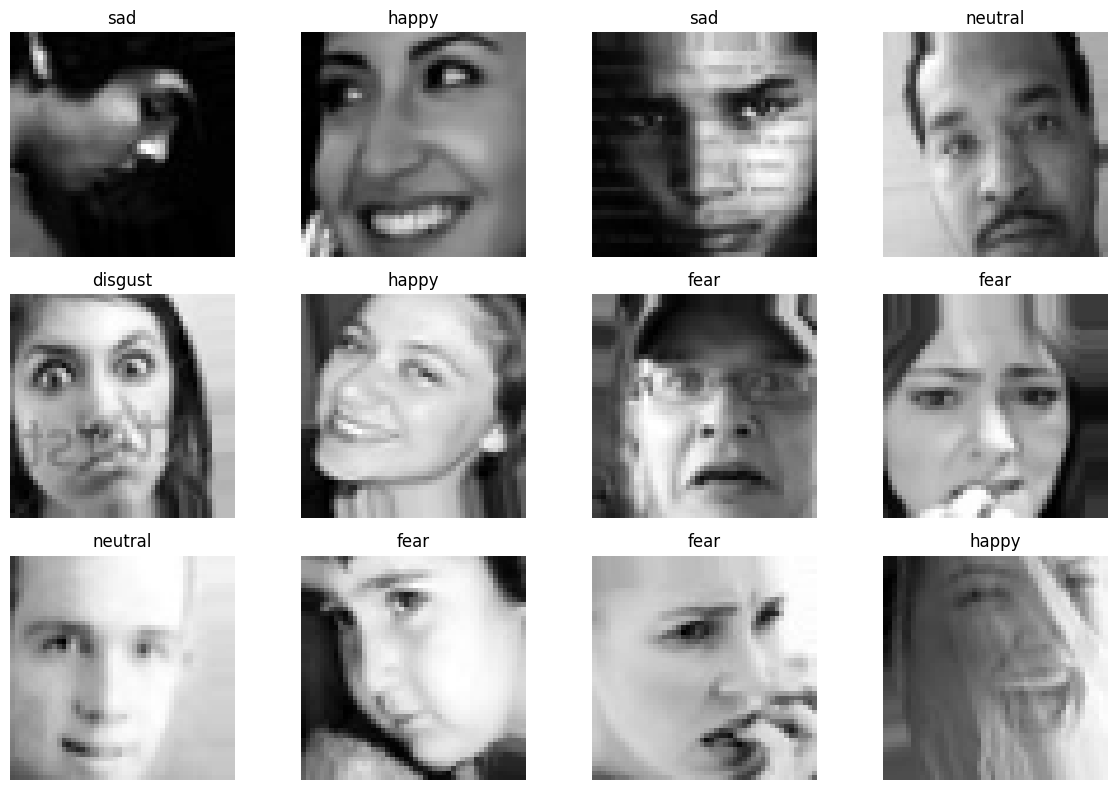

In [15]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    label_index = np.argmax(labels[i])
    label_name = classes[label_index]

    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
model = models.Sequential([

    # Input
    layers.Input(shape=(48, 48, 1)),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # CNN Block 4
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classification
    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(7, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,176,423 (4.49 MB)

 Trainable params: 1,174,951 (4.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [18]:
early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_face_expression_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [19]:
EPOCHS = 60

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

print("\nCNN TRAINING COMPLETED!")

Epoch 1/60
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.1889 - loss: 2.6297
Epoch 1: val_accuracy improved from None to 0.26026, saving model to best_face_expression_cnn.keras

Epoch 1: finished saving model to best_face_expression_cnn.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 55s 90ms/step - accuracy: 0.2064 - loss: 2.3380 - val_accuracy: 0.2603 - val_loss: 1.8946 - learning_rate: 5.0000e-04
Epoch 2/60
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2491 - loss: 1.9689
Epoch 2: val_accuracy improved from 0.26026 to 0.30371, saving model to best_face_expression_cnn.keras

Epoch 2: finished saving model to best_face_expression_cnn.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.2615 - loss: 1.9179 - val_accuracy: 0.3037 - val_loss: 1.8122 - learning_rate: 5.0000e-04
Epoch 3/60
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3056 - loss: 1.7786
Epoch 3: val_accuracy improved from 0.30371 to 0.38692, saving model to best_face_expression_cnn.keras

Epoch 

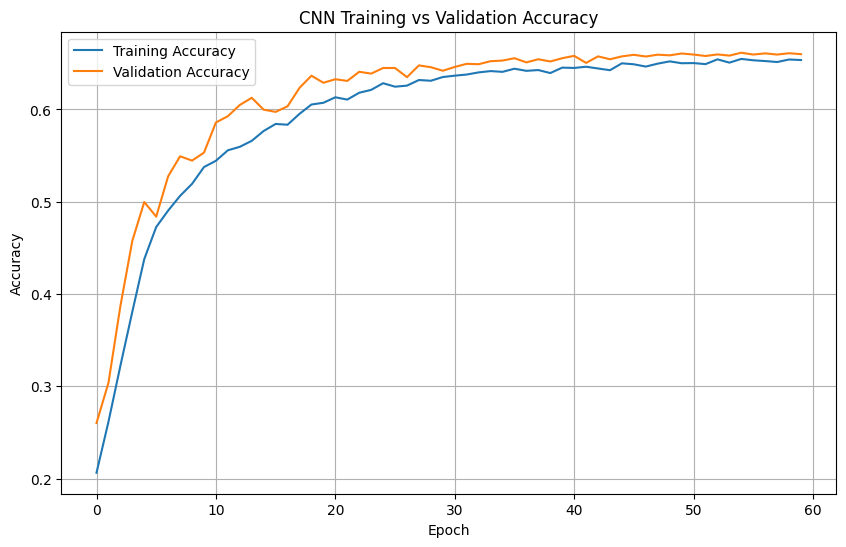

In [20]:
 plt.figure(figsize=(10, 6))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

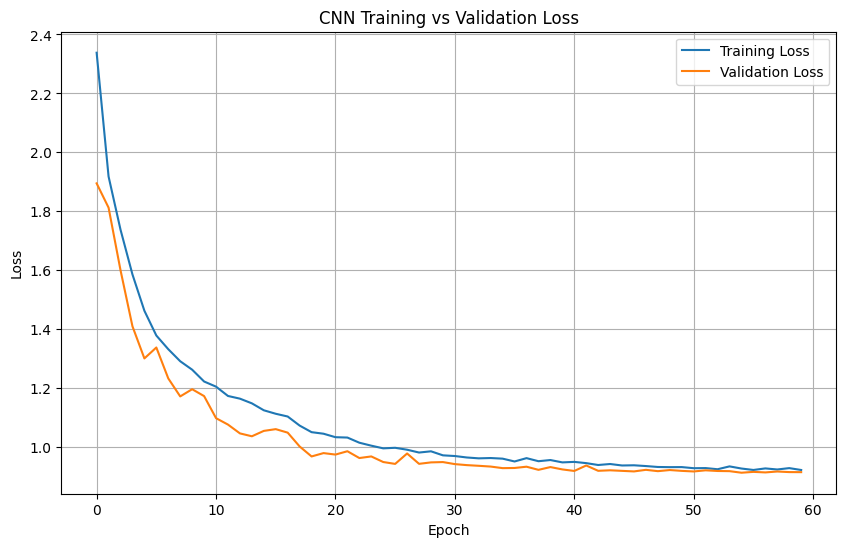

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
val_loss, val_accuracy = model.evaluate(
    val_generator,
    verbose=1
)

print("\nValidation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

print(f"\nValidation Accuracy: {val_accuracy * 100:.2f}%")

111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.6615 - loss: 0.9124

Validation Loss: 0.9124165177345276
Validation Accuracy: 0.6614775061607361

Validation Accuracy: 66.15%


In [23]:
# Reset generator
val_generator.reset()

# Get predictions
predictions = model.predict(val_generator, verbose=1)

# Convert probabilities to class numbers
y_pred = np.argmax(predictions, axis=1)

# Actual labels
y_true = val_generator.classes

print("Actual labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step
Actual labels shape: (7066,)
Predicted labels shape: (7066,)


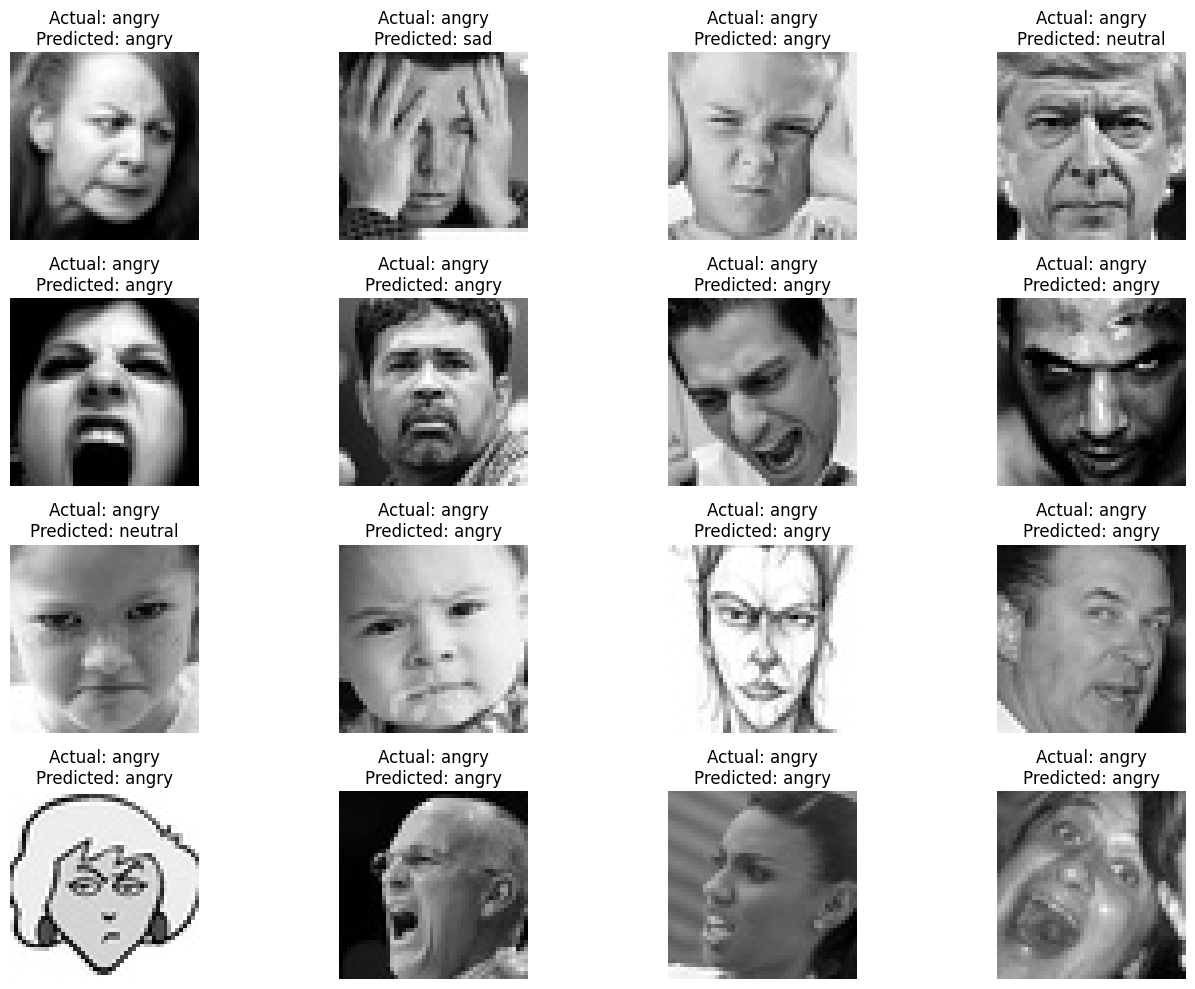

In [24]:
val_generator.reset()

images, labels = next(val_generator)

predictions = model.predict(images, verbose=0)

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(14, 10))

for i in range(16):
    plt.subplot(4, 4, i + 1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    actual = classes[actual_classes[i]]
    predicted = classes[predicted_classes[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        digits=4
    )
)

Classification Report:

              precision    recall  f1-score   support

       angry     0.5834    0.5500    0.5662       960
     disgust     0.7681    0.4775    0.5889       111
        fear     0.5752    0.3644    0.4462      1018
       happy     0.8636    0.8811    0.8723      1825
     neutral     0.5332    0.7459    0.6219      1216
         sad     0.5426    0.5198    0.5309      1139
    surprise     0.7755    0.7716    0.7736       797

    accuracy                         0.6615      7066
   macro avg     0.6631    0.6158    0.6286      7066
weighted avg     0.6640    0.6615    0.6556      7066



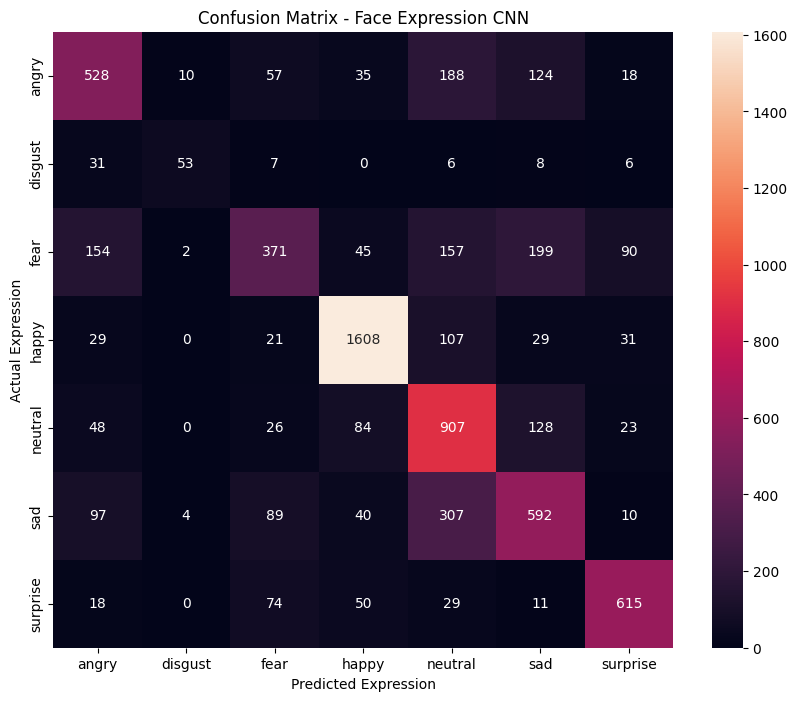

In [26]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Expression")
plt.ylabel("Actual Expression")
plt.title("Confusion Matrix - Face Expression CNN")

plt.show()

In [27]:
model.save("face_expression_cnn.keras")

print("Model saved successfully!")
print("File: face_expression_cnn.keras")

Model saved successfully!
File: face_expression_cnn.keras


In [28]:
loaded_model = tf.keras.models.load_model(
    "face_expression_cnn.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [35]:
from google.colab import files

uploaded = files.upload()

print("Image uploaded successfully!")

Saving Screenshot 2026-09-25 191802.png to Screenshot 2026-09-25 191802 (1).png
Image uploaded successfully!


In [36]:
from tensorflow.keras.utils import load_img, img_to_array

image_name = list(uploaded.keys())[0]

img = load_img(
    image_name,
    target_size=(48, 48),
    color_mode="grayscale"
)

img_array = img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction[0])

predicted_expression = classes[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("Predicted Expression:", predicted_expression)
print(f"Confidence: {confidence:.2f}%")

Predicted Expression: angry
Confidence: 62.49%


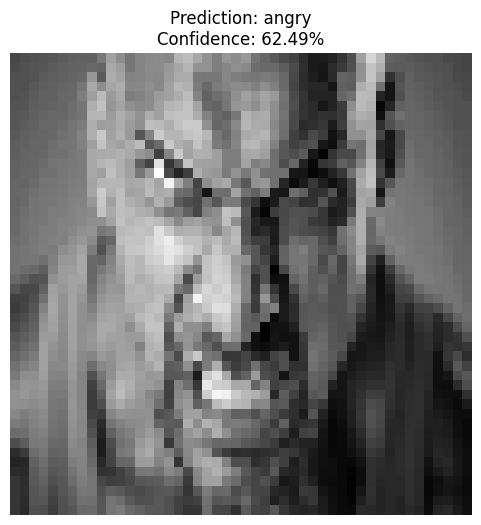

In [37]:
plt.figure(figsize=(6, 6))

plt.imshow(img, cmap="gray")

plt.title(
    f"Prediction: {predicted_expression}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

In [38]:
print("=" * 50)
print("FACE EXPRESSION RECOGNITION USING CNN")
print("=" * 50)

print(f"Number of Classes     : {len(classes)}")
print(f"Training Images       : {train_generator.samples}")
print(f"Validation Images     : {val_generator.samples}")
print(f"Image Size            : {IMG_SIZE} x {IMG_SIZE}")
print(f"Batch Size            : {BATCH_SIZE}")
print(f"Validation Accuracy   : {val_accuracy * 100:.2f}%")
print("=" * 50)

print("Expression Classes:")
for i, cls in enumerate(classes):
    print(f"{i}: {cls}")

print("=" * 50)
print("CNN FACE EXPRESSION PROJECT COMPLETED")
print("=" * 50)

FACE EXPRESSION RECOGNITION USING CNN
Number of Classes     : 7
Training Images       : 28821
Validation Images     : 7066
Image Size            : 48 x 48
Batch Size            : 64
Validation Accuracy   : 66.15%
Expression Classes:
0: angry
1: disgust
2: fear
3: happy
4: neutral
5: sad
6: surprise
CNN FACE EXPRESSION PROJECT COMPLETED
